# Projeto 01: Kaggle Tabular Playground Series
## Competição Escolhida

**Grupo:** H  
**Alunos:** Lucas de Oliveira Ferreira / Luis Enrique Asuncion Velasquez    
**Nome da competição:** Binary Classification with a Bank Dataset.  
**Temporada e episódio:** Temporada 05, episódio 08.  
**Link da competição:** [Binary Classification with a Bank Dataset](https://www.kaggle.com/competitions/playground-series-s5e8/overview)

# Bank Term Deposit Subscription Prediction Dataset

## Objetivo
Prever se um cliente irá assinar um depósito a prazo bancário

## Descrição
O conjunto de dados para esta competição (tanto de treino quanto de teste) foi gerado a partir de um modelo de deep learning treinado sobre o [Bank Marketing Dataset](https://www.kaggle.com/datasets/sushant097/bank-marketing-dataset-full/data). As distribuições das variáveis estão próximas, mas não exatamente iguais, às do original. Sinta-se à vontade para usar o conjunto de dados original como parte desta competição, tanto para explorar as diferenças quanto para verificar se incorporá-lo ao treinamento melhora o desempenho do modelo.

## Conteúdo do Dataset
O dataset de treinamento contém **750.000 registros** com **17 atributos**.  
Os atributos representam informações do cliente e detalhes da campanha, incluindo dados categóricos e numéricos.  

- **age:** Idade do cliente (numérico)  
- **job:** Tipo de trabalho (categórico: "admin.", "blue-collar", "entrepreneur", etc.)  
- **marital:** Estado civil (categórico: "married", "single", "divorced")  
- **education:** Nível de educação (categórico: "primary", "secondary", "tertiary", "unknown")  
- **default:** Possui crédito em inadimplência? (categórico: "yes", "no")  
- **balance:** Saldo médio anual em euros (numérico)  
- **housing:** Possui empréstimo habitacional? (categórico: "yes", "no")  
- **loan:** Possui empréstimo pessoal? (categórico: "yes", "no")  
- **contact:** Tipo de contato de comunicação (categórico: "unknown", "telephone", "cellular")  
- **day:** Último dia de contato do mês (numérico, 1–31)  
- **month:** Último mês de contato do ano (categórico: "jan", "feb", "mar", …, "dec")  
- **duration:** Duração do último contato em segundos (numérico)  
- **campaign:** Número de contatos realizados durante esta campanha (numérico)  
- **pdays:** Número de dias desde que o cliente foi contatado pela última vez em uma campanha anterior (numérico; **-1 significa que o cliente não foi contatado anteriormente**)  
- **previous:** Número de contatos realizados antes desta campanha (numérico)  
- **poutcome:** Resultado da campanha de marketing anterior (categórico: "unknown", "other", "failure", "success")  
- **y:** Variável alvo, se o cliente assinou ou não um depósito a prazo (binário: "yes", "no")

O dataset de teste contém **250.000 registros** com os mesmos atributos com exceção do atributo alvo "y".


# Instalando e Importando Bibliotecas

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from IPython.display import display

# Importando Datasets

Caso queira rodar o Dataset é necessário criar uma API no kaggle e logar abaixo. Possivelmente também é necessário que você entre no kaggle com sua conta e participe da competição.

In [ ]:
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
dataset_path = kagglehub.competition_download('playground-series-s5e8')

print("Arquivos disponíveis:")
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

100%|██████████| 14.7M/14.7M [00:01<00:00, 10.5MB/s]

Extracting files...


Arquivos disponíveis:
/root/.cache/kagglehub/competitions/playground-series-s5e8/train.csv
/root/.cache/kagglehub/competitions/playground-series-s5e8/sample_submission.csv
/root/.cache/kagglehub/competitions/playground-series-s5e8/test.csv


In [ ]:
path_test = os.path.join(dataset_path, 'test.csv')
path_train = os.path.join(dataset_path, 'train.csv')
path_sample = os.path.join(dataset_path, 'sample_submission.csv')

df_test = pd.read_csv(path_test, index_col='id')
df_train = pd.read_csv(path_train, index_col='id')
df_sample = pd.read_csv(path_sample, index_col='id')

In [ ]:
df_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
id,,,,,,,,,,,,,,,,,
0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [ ]:
df_test.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
id,,,,,,,,,,,,,,,,
750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


# Pré-Processamento

Checando informações principais do dataframe

In [ ]:
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   age        750000 non-null  int64 
 1   job        750000 non-null  object
 2   marital    750000 non-null  object
 3   education  750000 non-null  object
 4   default    750000 non-null  object
 5   balance    750000 non-null  int64 
 6   housing    750000 non-null  object
 7   loan       750000 non-null  object
 8   contact    750000 non-null  object
 9   day        750000 non-null  int64 
 10  month      750000 non-null  object
 11  duration   750000 non-null  int64 
 12  campaign   750000 non-null  int64 
 13  pdays      750000 non-null  int64 
 14  previous   750000 non-null  int64 
 15  poutcome   750000 non-null  object
 16  y          750000 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 103.0+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 250000 entries, 750000 to 999999
Data

In [ ]:
df_train.describe()

,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [ ]:
df_test.describe()

,age,balance,day,duration,campaign,pdays,previous
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,40.932332,1197.426352,16.116068,255.342260,2.573548,22.280028,0.303728
std,10.081613,2741.520699,8.258509,271.404326,2.709661,76.915879,1.384574
min,18.000000,-8019.000000,1.000000,3.000000,1.000000,-1.000000,0.000000
25%,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000
50%,39.000000,631.000000,17.000000,133.000000,2.000000,-1.000000,0.000000
75%,48.000000,1389.000000,21.000000,353.000000,3.000000,-1.000000,0.000000
max,95.000000,98517.000000,31.000000,4918.000000,58.000000,871.000000,150.000000


In [ ]:
df_train.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df_test.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
# Atributos categóricos
df_train.select_dtypes(include=['object']).columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

In [ ]:
# Valores únicos de cada atributo categórico
for col in df_train.select_dtypes(include=['object']).columns:
    print(f"--- {col} ---")
    print(df_train[col].unique())
    print()

--- job ---
['technician' 'blue-collar' 'student' 'admin.' 'management' 'entrepreneur'
 'self-employed' 'unknown' 'services' 'retired' 'housemaid' 'unemployed']

--- marital ---
['married' 'single' 'divorced']

--- education ---
['secondary' 'primary' 'tertiary' 'unknown']

--- default ---
['no' 'yes']

--- housing ---
['no' 'yes']

--- loan ---
['no' 'yes']

--- contact ---
['cellular' 'unknown' 'telephone']

--- month ---
['aug' 'jun' 'may' 'feb' 'apr' 'nov' 'jul' 'jan' 'oct' 'mar' 'sep' 'dec']

--- poutcome ---
['unknown' 'other' 'failure' 'success']



Os atributos categoricos podem ser divididos entre atributos com ordem e sem ordem, usaremos os métodos OrdinalEncoder, OneHotEncoder e Codificação Binária para transformá-los em valores numéricos.

In [ ]:
# 1) ORDINAIS
education_order = ["unknown", "primary", "secondary", "tertiary"]
oe_edu = OrdinalEncoder(categories=[education_order],
                        handle_unknown="use_encoded_value", unknown_value=np.nan)
df_train["education"] = oe_edu.fit_transform(df_train[["education"]]).astype("int64")
df_test["education"] = oe_edu.transform(df_test[["education"]]).astype("int64")

month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
oe_month = OrdinalEncoder(categories=[month_order],
                          handle_unknown="use_encoded_value", unknown_value=np.nan)
df_train["month"] = oe_month.fit_transform(df_train[["month"]]).astype("int64")
df_test["month"] = oe_month.transform(df_test[["month"]]).astype("int64")

# 2) BINARIO
yesno_cols = ["default", "housing", "loan"]
for c in yesno_cols:
    df_train[c] = df_train[c].map({"no": 0, "yes": 1}).astype("int64")
    df_test[c] = df_test[c].map({"no": 0, "yes": 1}).astype("int64")

# 3) ONE-HOT
onehot_cols = ["job", "marital", "contact", "poutcome"]

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_array = ohe.fit_transform(df_train[onehot_cols])

encoded_col_names = ohe.get_feature_names_out(onehot_cols)

encoded_df = pd.DataFrame(encoded_array, columns=encoded_col_names, index=df_train.index).astype("int8")

df_train.drop(columns=onehot_cols, inplace=True)
df_train = pd.concat([df_train, encoded_df], axis=1)

display(df_train.head())

encoded_array = ohe.transform(df_test[onehot_cols])

encoded_col_names = ohe.get_feature_names_out(onehot_cols)

encoded_df = pd.DataFrame(encoded_array, columns=encoded_col_names, index=df_test.index).astype("int8")

df_test.drop(columns=onehot_cols, inplace=True)
df_test = pd.concat([df_test, encoded_df], axis=1)

display(df_test.head())

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
id,,,,,,,,,,,,,,,,,,,,,
0,42,2,0,7,0,0,25,7,117,3,...,0,1,0,1,0,0,0,0,0,1
1,38,2,0,514,0,0,18,5,185,1,...,0,1,0,0,0,1,0,0,0,1
2,36,2,0,602,1,0,14,4,111,2,...,0,1,0,0,0,1,0,0,0,1
3,27,2,0,34,1,0,28,4,10,2,...,0,0,1,0,0,1,0,0,0,1
4,26,2,0,889,1,0,3,1,902,1,...,0,1,0,1,0,0,0,0,0,1


,age,education,default,balance,housing,loan,day,month,duration,campaign,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
id,,,,,,,,,,,,,,,,,,,,,
750000,32,2,0,1397,1,0,21,4,224,1,...,0,1,0,0,0,1,0,0,0,1
750001,44,3,0,23,1,0,3,3,586,2,...,0,1,0,1,0,0,0,0,0,1
750002,36,1,0,46,1,1,13,4,111,2,...,0,1,0,1,0,0,0,0,0,1
750003,58,2,0,-1380,1,1,29,4,125,1,...,0,1,0,0,0,1,0,0,0,1
750004,28,2,0,1950,1,0,22,6,181,1,...,0,0,1,1,0,0,0,0,0,1


A variável pdays possue valores -1 indicando que não foram feitos contatos previamente.

Para evitá-los, criaremos uma nova coluna para representar se foram ou não realizados contatos anteriormente e também ajustaremos os valores negativos da variável pdays para um valor padronizado 1600, que é maior que o máximo dos conjuntos de treino e teste.

In [ ]:
# Criar nova coluna indicando se houve contato anterior
df_train["was_contacted"] = (df_train["pdays"] != -1).astype(int)

# Substituir valores -1 por 999 em 'pdays'
df_train["pdays"] = df_train["pdays"].replace(-1, 1600)
df_test["pdays"] = df_test["pdays"].replace(-1, 1600)

# Análise Inicial

### Distribuição da Variável Alvo

A análise da distribuição da variável alvo nos mostrou uma grande diferença na porcentagem de cada classe, indicando que técnicas como undersampling ou adoção de pesos deverão ser utilizadas durante o treinamento do modelo preditivo.

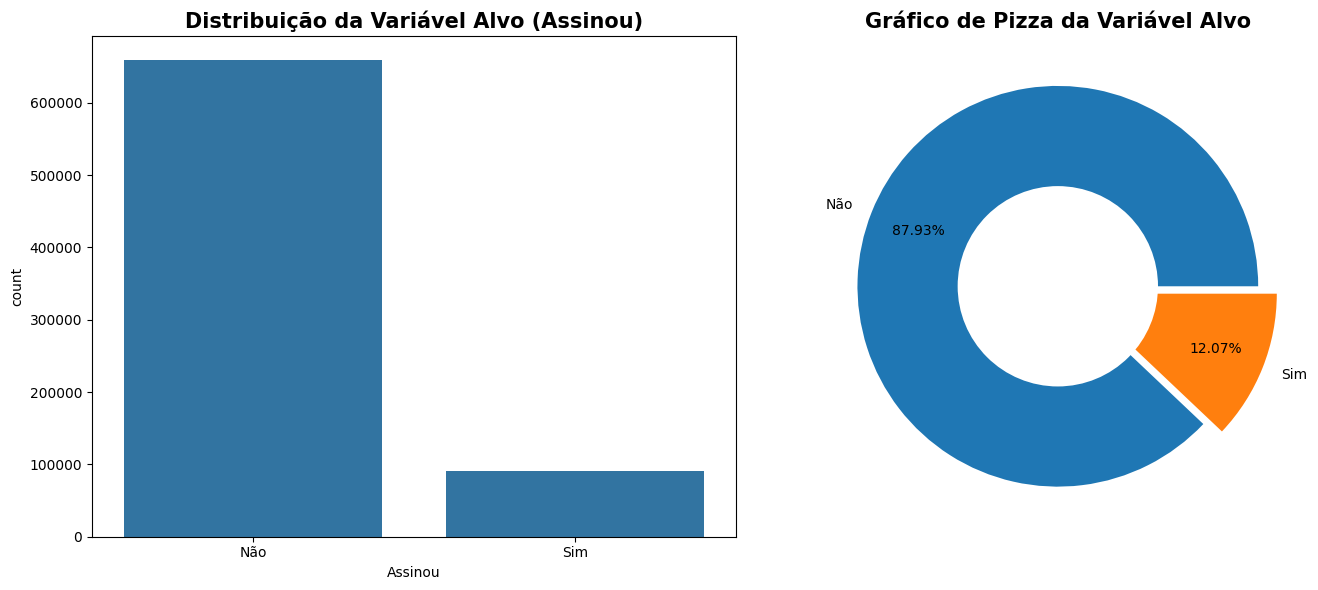

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de contagem
sns.countplot(x='y', data=df_train, ax=axes[0])
axes[0].set_title('Distribuição da Variável Alvo (Assinou)', fontweight='bold', size=15)
axes[0].set_xticks(ticks=[0, 1], labels=['Não', 'Sim'])
axes[0].set_xlabel("Assinou")

# Gráfico de pizza
df_train['y'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    explode=(0.0, 0.1),
    autopct="%.2f%%",
    labels=['Não', 'Sim'],
    pctdistance=0.75
)
axes[1].add_artist(plt.Circle((0, 0), 0.5, fc='w'))
axes[1].set_title('Gráfico de Pizza da Variável Alvo', fontweight='bold', size=15)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Verificando se categorias **_unknown** e **marital_single** podem ser dropadas



In [ ]:
check_contact = (
    (df_train[["contact_cellular","contact_telephone"]].sum(axis=1) == 0)
    == (df_train["contact_unknown"] == 1)
).all()

print("contact_unknown é complemento perfeito das demais?", check_contact)

contact_unknown é complemento perfeito das demais? True


In [ ]:
check_poutcome = (
    (df_train[["poutcome_failure","poutcome_other","poutcome_success"]].sum(axis=1) == 0)
    == (df_train["poutcome_unknown"] == 1)
).all()

print("poutcome_unknown é complemento perfeito das demais?", check_poutcome)

poutcome_unknown é complemento perfeito das demais? True


In [ ]:
job_cols = [c for c in df_train.columns if c.startswith("job_") and c!="job_unknown"]
check_job = (
    (df_train[job_cols].sum(axis=1) == 0)
    == (df_train["job_unknown"] == 1)
).all()

print("job_unknown é complemento perfeito das demais?", check_job)

job_unknown é complemento perfeito das demais? True


In [ ]:
check_marital = (
    (df_train[["marital_divorced","marital_married"]].sum(axis=1) == 0)
    == (df_train["marital_single"] == 1)
).all()

print("marital_single é complemento perfeito das demais?", check_marital)

marital_single é complemento perfeito das demais? True


Nesse caso podemos dropar essas colunas por serem linearmente dependentes de seus pares.

In [ ]:
# Identifica todas as colunas que terminam com "_unknown"
unknown_cols = [c for c in df_train.columns if c.endswith("_unknown")]
unknown_cols.append("marital_single")

print("Colunas a serem dropadas:", unknown_cols)

# Dropa do DataFrame
df_train = df_train.drop(columns=unknown_cols)

print("Novo shape:", df_train.shape)

Colunas a serem dropadas: ['job_unknown', 'contact_unknown', 'poutcome_unknown', 'marital_single']
Novo shape: (750000, 32)


### Analisando Exemplos e Verificando Outliers

In [ ]:
df_train[["age", "balance", "duration", "campaign", "pdays", "previous"]].describe(percentiles=[.01, .05, .95, .99])

,age,balance,duration,campaign,pdays,previous
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,40.926395,1204.067397,256.229144,2.577008,1457.835179,0.298545
std,10.098829,2836.096759,272.555662,2.718514,420.045262,1.335926
min,18.000000,-8019.000000,1.000000,1.000000,0.000000,0.000000
1%,24.000000,-974.000000,7.000000,1.000000,92.000000,0.000000
5%,27.000000,-287.000000,27.000000,1.000000,185.000000,0.000000
50%,39.000000,634.000000,133.000000,2.000000,1600.000000,0.000000
95%,58.000000,4493.000000,829.000000,7.000000,1600.000000,2.000000
99%,66.000000,10861.000000,1206.000000,14.000000,1600.000000,6.000000
max,95.000000,99717.000000,4918.000000,63.000000,1600.000000,200.000000


Foi possível verificar:

1. Valores extremos (outliers)

**balance**: varia de -8019 até 99.717, com média de apenas ~1204. Isso sugere muitos valores extremos (tanto negativos quanto muito altos).

**duration**: máximo de quase 5000, quando a mediana é só 133. Tem forte assimetria.

**campaign**: a maioria é baixa (mediana=2), mas chega até 63. O mesmo vale para previous (vai até 200, mas a maior parte é 0).

- Aplicar winsorization (cortar nos percentis 1% e 99%);  
- Ou usar transformações logarítmicas (log(1+x)) se fizer sentido para reduzir a escala.  

---

2. Normalização / Padronização  

As variáveis estão em escalas muito diferentes:  

**age**: vai de 18 a 95;  
**balance**: vai de -8k a 100k;  
**duration**: até ~5000.  

É essencial aplicar algum Scaler caso seja utilizado posteriormente algum algoritmo sensível à escala (ex: regressão logística, SVM, redes neurais).


### Verificando correlações

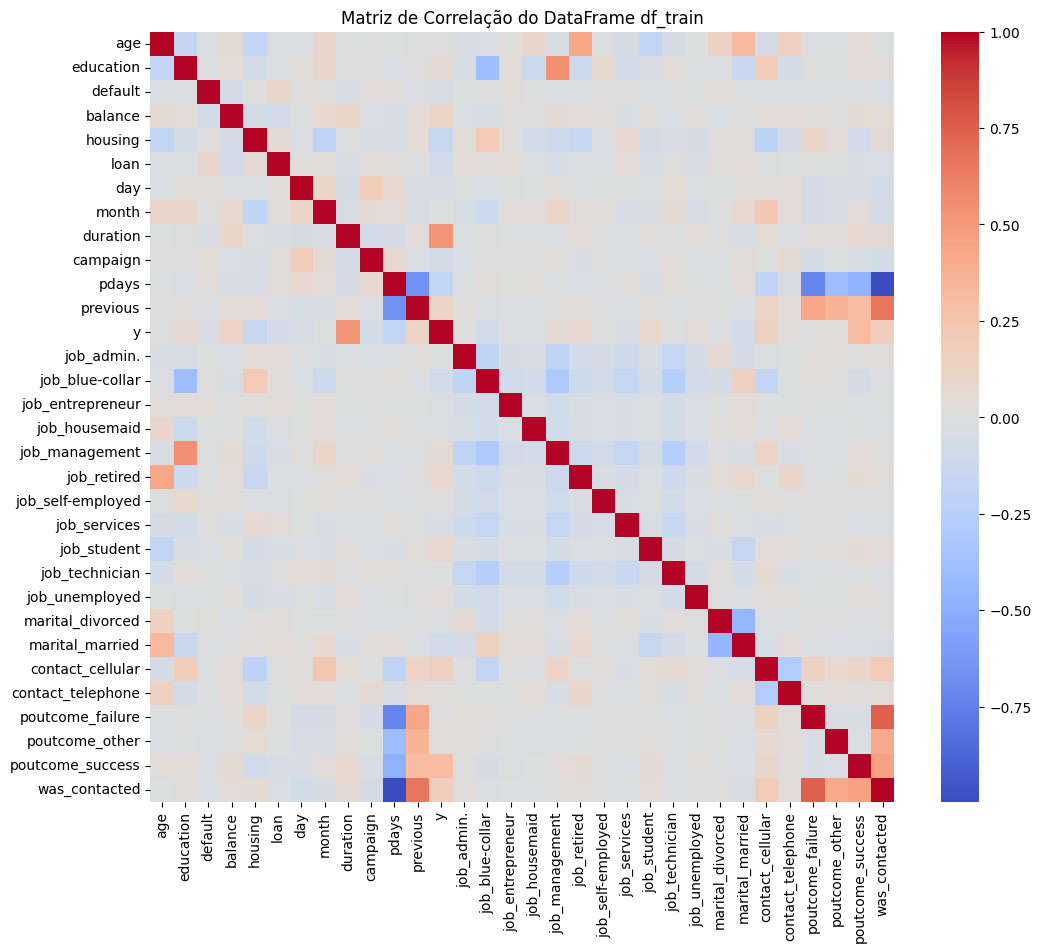

In [ ]:
correlation_matrix = df_train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação do DataFrame df_train')
plt.show()

Abaixo mostramos as top correlações da variável alvo e as top correlações gerais também, para facilitar interpretação (matriz de correlação é muito grande).

In [ ]:
X = df_train.drop(columns=["y"])
y = df_train["y"]

print("Formas -> X:", X.shape, "| y:", y.shape)

Formas -> X: (750000, 31) | y: (750000,)


In [ ]:
# Correlação de cada feature com o alvo (numérico)
corr_with_target = {}
for col in X.columns:
    corr_with_target[col] = X[col].corr(y)   # correlação direta

corr_with_target = pd.Series(corr_with_target).sort_values(key=lambda s: s.abs(), ascending=False)
print(corr_with_target.head(20))

# Pares de features mais colineares (|corr| alto)
corr_matrix = X.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_pairs = upper.stack().sort_values(ascending=False)
print("\nPares com maior colinearidade (top 20):\n", high_pairs.head(20))

duration            0.519283
poutcome_success    0.306996
pdays              -0.180259
was_contacted       0.169470
housing            -0.153589
contact_cellular    0.149948
balance             0.122513
previous            0.119552
job_blue-collar    -0.088614
job_retired         0.085545
job_student         0.085325
loan               -0.081639
marital_married    -0.077038
campaign           -0.075829
education           0.071242
job_management      0.050475
day                -0.049625
job_services       -0.035638
default            -0.030134
job_unemployed      0.028189
dtype: float64

Pares com maior colinearidade (top 20):
 pdays             was_contacted        0.996519
poutcome_failure  was_contacted        0.744666
pdays             poutcome_failure     0.727775
                  previous             0.660127
previous          was_contacted        0.657872
education         job_management       0.543480
pdays             poutcome_success     0.482417
poutcome_success  was_conta

### Remoção de features de alta correlação

Nesse caso não foram identificadas features com correlação alta o suficiente para que fossem removidas.

In [ ]:
# Threshold de correlação entre features
corr_thr = 0.95

corr_matrix = X.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > corr_thr)]

X_nc = X.drop(columns=to_drop)
print(f"Removidas {len(to_drop)} features por alta colinearidade (>|{corr_thr}|).")
print("Shape após filtro:", X_nc.shape)

Removidas 1 features por alta colinearidade (>|0.95|).
Shape após filtro: (750000, 30)


In [ ]:
X_nc.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_divorced',
       'marital_married', 'contact_cellular', 'contact_telephone',
       'poutcome_failure', 'poutcome_other', 'poutcome_success'],
      dtype='object')

Matriz de Correlação após alterações

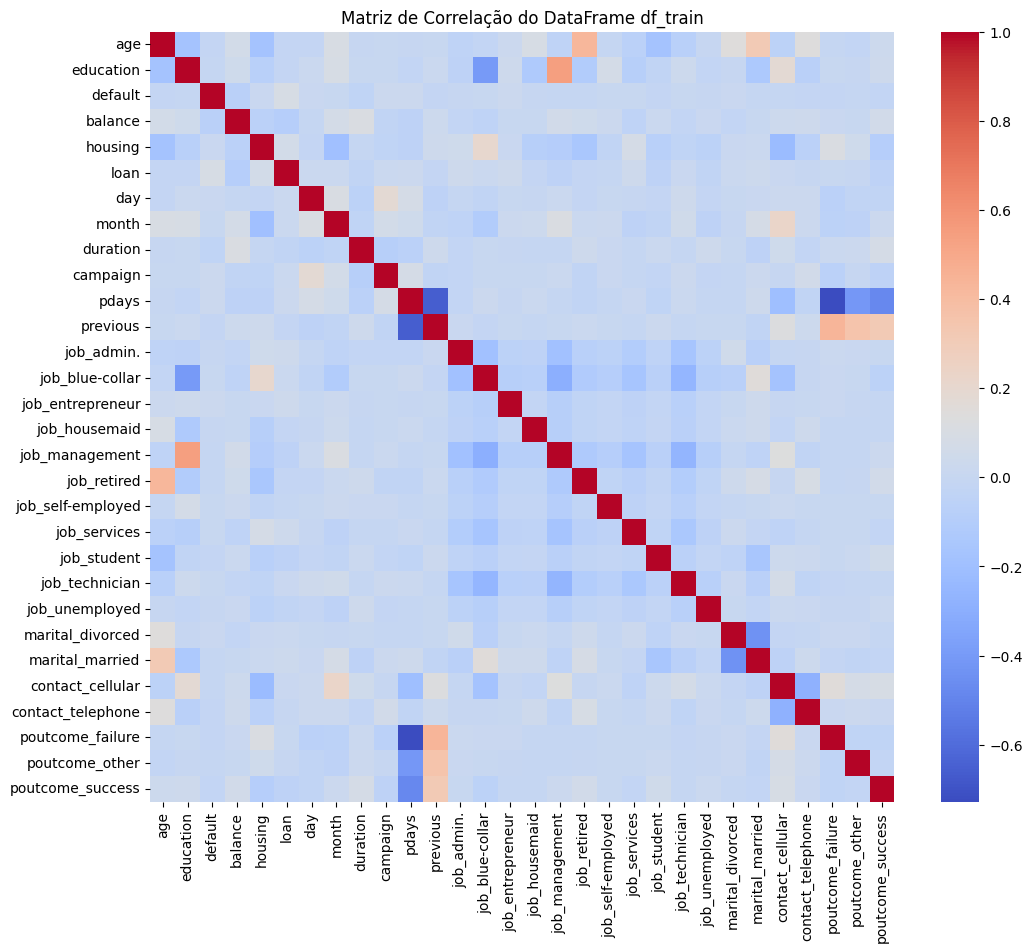

In [ ]:
correlation_matrix = X_nc.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação do DataFrame df_train')
plt.show()

# Plano de Projeto



Com base na análise inicial do dataset, elaboramos o seguinte plano de execução para o desenvolvimento do modelo preditivo.

## 1. Entendimento dos Dados
Já realizamos uma primeira análise exploratória que nos permitiu entender as variáveis disponíveis, suas distribuições e a natureza da variável alvo (`y`). Verificamos que:

- Existem variáveis numéricas e categóricas.
- Algumas variáveis apresentam valores extremos (outliers).
- A variável alvo é **desequilibrada**, com muito mais "não" do que "sim".

## 2. Pré-processamento

Vamos aplicar as seguintes etapas de preparação dos dados:

- **Tratamento de valores ausentes e codificação de variáveis categóricas:**
  - `OrdinalEncoder` para variáveis com ordem (ex: `education`, `month`);
  - `OneHotEncoder` para variáveis nominais;
  - Conversão binária (`yes`/`no`) em 0/1.
- **Engenharia de atributos:**
  - Criação da variável `was_contacted` a partir de `pdays`;
  - Substituição de valores especiais (-1) por constantes padronizadas.
- **Detecção e tratamento de outliers:**
  - Usar percentis (1% e 99%) para identificar valores extremos;
  - Avaliar o uso de Winsorization ou transformações logarítmicas.
- **Normalização/Escalonamento:**
  - A princípio não é necessária para modelos baseados em árvores, mas pode ser usada caso testemos modelos como SVM ou redes neurais.

## 3. Balanceamento das Classes

Como a variável alvo é desbalanceada, consideraremos técnicas para lidar com isso:

- Uso de **pesos** nas instâncias no momento do treinamento;
- Ou aplicação de **undersampling/oversampling**, dependendo do modelo adotado.

## 4. Modelagem

Ainda estamos avaliando os modelos mais adequados, mas os candidatos iniciais são:

- Modelos baseados em árvores: **LightGBM**, **XGBoost**, **Random Forest**;
- Caso necessário, testar modelos lineares ou redes neurais com ajustes na escala.

Etapas previstas:

- Treinar modelos base usando validação cruzada;
- Ajustar hiperparâmetros com grid search ou similar;
- Avaliar métricas relevantes (como AUC, F1, recall da classe minoritária).

## 5. Geração de Predições

Após o treinamento e validação, aplicaremos o modelo final ao conjunto `test.csv` e geraremos o arquivo `submission.csv` conforme o formato da competição.

## 6. Avaliação de Desempenho e Melhorias

Durante o processo, vamos registrar:

- Quais técnicas geraram melhores resultados;
- Como cada etapa influenciou no desempenho final;
- Possíveis melhorias (como seleção de features, ensemble, stacking, etc.).

## 7. Dificuldades e Riscos Previstos

- **Desbalanceamento das classes** pode impactar negativamente na performance.
- **Valores extremos** e **escalas diferentes** entre variáveis podem prejudicar alguns modelos.
- Decidir a melhor **estratégia de pré-processamento** para diferentes tipos de variável.
- Necessidade de testes com diferentes algoritmos e abordagens de validação.

Apesar disso, o dataset é relativamente limpo, com poucas ausências e estrutura tabular clara o que facilita a manipulação.


# Model Training

## 1) Divisão Estratificada: treino vs. validação

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_nc, y, test_size=0.20, random_state=42, stratify=y
)

print("Shapes ->")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "| y_val  :", y_val.shape)
print("\nProporção classe positiva no treino:", y_train.mean().round(4))
print("Proporção classe positiva na validação:", y_val.mean().round(4))

Shapes ->
X_train: (600000, 30) | y_train: (600000,)
X_val  : (150000, 30) | y_val  : (150000,)

Proporção classe positiva no treino: 0.1206
Proporção classe positiva na validação: 0.1207


## 2) Baseline com Random Forest

AUC (val): 0.9629

Relatório (limiar 0.5):
              precision    recall  f1-score   support

           0     0.9486    0.9731    0.9607    131902
           1     0.7584    0.6158    0.6797     18098

    accuracy                         0.9300    150000
   macro avg     0.8535    0.7944    0.8202    150000
weighted avg     0.9257    0.9300    0.9268    150000



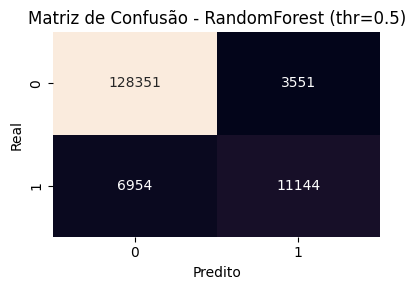

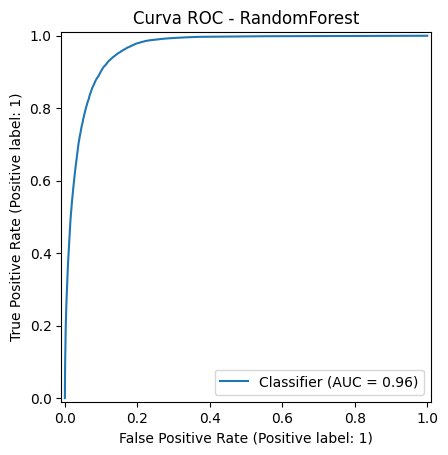

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Treino do baseline
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    n_jobs=-1,
    class_weight="balanced",   # lida com desbalanceamento
    random_state=42
)
rf.fit(X_train, y_train)

# 2) Predições na validação
y_pred_val  = rf.predict(X_val)
y_proba_val = rf.predict_proba(X_val)[:, 1]

# 3) Métricas
print("AUC (val):", roc_auc_score(y_val, y_proba_val).round(4))
print("\nRelatório (limiar 0.5):")
print(classification_report(y_val, y_pred_val, digits=4))

# 4) Matriz de confusão
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.title("Matriz de Confusão - RandomForest (thr=0.5)")
plt.xlabel("Predito"); plt.ylabel("Real")
plt.tight_layout()
plt.show()

# 5) Curva ROC
RocCurveDisplay.from_predictions(y_val, y_proba_val)
plt.title("Curva ROC - RandomForest")
plt.show()

## 3) Ajuste do Threshold

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Lista de thresholds de 0.05 até 0.95 (de 5% a 95%)
thr_grid = np.linspace(0.05, 0.95, 19)
resultados = []

for thr in thr_grid:
    y_hat = (y_proba_val >= thr).astype(int)
    f1 = f1_score(y_val, y_hat)
    rec = recall_score(y_val, y_hat)
    prec = precision_score(y_val, y_hat)
    resultados.append((thr, f1, rec, prec))

# Organizar e mostrar os melhores thresholds
df_thr = pd.DataFrame(resultados, columns=["threshold", "f1", "recall", "precision"])
df_thr = df_thr.sort_values("f1", ascending=False).reset_index(drop=True)

# Mostrar top 5 melhores thresholds por F1
print("Top 5 thresholds por F1:")
display(df_thr.head())

# Salvar o melhor threshold encontrado
best_thr = df_thr.loc[0, "threshold"]

Top 5 thresholds por F1:


,threshold,f1,recall,precision
0,0.35,0.719572,0.765057,0.679192
1,0.30,0.719406,0.808984,0.647689
2,0.40,0.714685,0.721240,0.708247
3,0.25,0.712361,0.851641,0.612234
4,0.45,0.700663,0.671124,0.732923


## 4) Reavaliação com Novo Threshold (thr = 0.35)

Relatório de Classificação - Threshold 0.35
              precision    recall  f1-score   support

           0     0.9672    0.9504    0.9587    131902
           1     0.6792    0.7651    0.7196     18098

    accuracy                         0.9281    150000
   macro avg     0.8232    0.8577    0.8392    150000
weighted avg     0.9324    0.9281    0.9299    150000



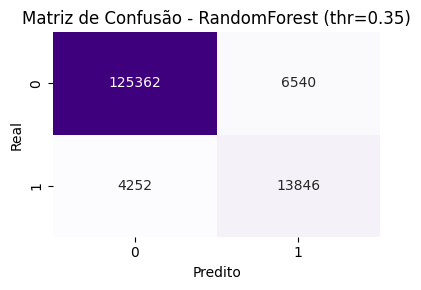

In [ ]:
# Aplicar novo threshold
thr_final = 0.35
y_pred_final = (y_proba_val >= thr_final).astype(int)

# Avaliar com novas métricas
print(f"Relatório de Classificação - Threshold {thr_final}")
print(classification_report(y_val, y_pred_final, digits=4))

# Nova matriz de confusão
cm_final = confusion_matrix(y_val, y_pred_final)
plt.figure(figsize=(4,3))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title(f"Matriz de Confusão - RandomForest (thr={thr_final})")
plt.xlabel("Predito"); plt.ylabel("Real")
plt.tight_layout()
plt.show()

## 5) Baseline com LightGBM

In [ ]:
!pip install lightgbm

[LightGBM] [Info] Number of positive: 72390, number of negative: 527610
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034938 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1006
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120650 -> initscore=-1.986289
[LightGBM] [Info] Start training from score -1.986289
AUC (val) - LightGBM: 0.9679

Relatório de classificação (thr = 0.5):
              precision    recall  f1-score   support

           0     0.9896    0.8879    0.9360    131902
           1     0.5330    0.9323    0.6782     18098

    accuracy                         0.8933    150000
   macro avg     0.7613    0.9101    0.8071    150000
weighted avg     0.9345    0.8933    0.9049    150000



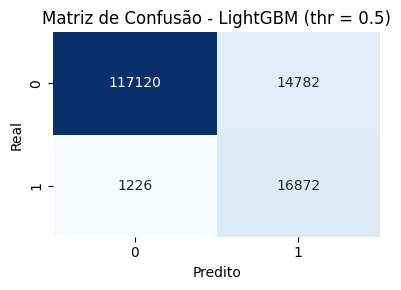

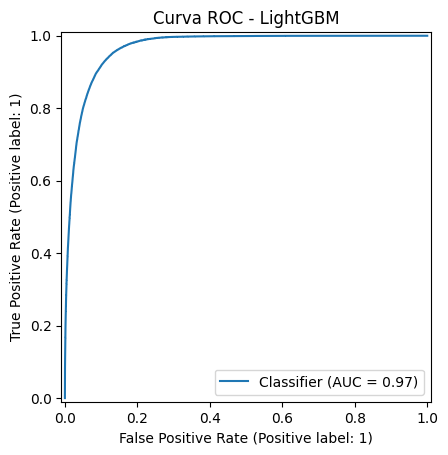

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

# Peso inverso ao desbalanceamento
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Modelo baseline LightGBM
lgb = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

# Treinamento
lgb.fit(X_train, y_train)

# Previsões
y_proba_val_lgb = lgb.predict_proba(X_val)[:, 1]
y_pred_val_lgb = (y_proba_val_lgb >= 0.5).astype(int)

print("AUC (val) - LightGBM:", roc_auc_score(y_val, y_proba_val_lgb).round(4))
print("\nRelatório de classificação (thr = 0.5):")
print(classification_report(y_val, y_pred_val_lgb, digits=4))

# Matriz de confusão
cm_lgb = confusion_matrix(y_val, y_pred_val_lgb)
plt.figure(figsize=(4,3))
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de Confusão - LightGBM (thr = 0.5)")
plt.xlabel("Predito"); plt.ylabel("Real")
plt.tight_layout()
plt.show()

# Curva ROC
RocCurveDisplay.from_predictions(y_val, y_proba_val_lgb)
plt.title("Curva ROC - LightGBM")
plt.show()

## 6) Ajuste do Threshold para LightGBM

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score

thr_grid_lgb = np.linspace(0.05, 0.95, 19)
resultados_lgb = []

for thr in thr_grid_lgb:
    y_hat_lgb = (y_proba_val_lgb >= thr).astype(int)
    f1 = f1_score(y_val, y_hat_lgb)
    rec = recall_score(y_val, y_hat_lgb)
    prec = precision_score(y_val, y_hat_lgb)
    resultados_lgb.append((thr, f1, rec, prec))

# Organizar resultados
df_thr_lgb = pd.DataFrame(resultados_lgb, columns=["threshold", "f1", "recall", "precision"])
df_thr_lgb = df_thr_lgb.sort_values("f1", ascending=False).reset_index(drop=True)

# Mostrar top 5
print("Top 5 thresholds por F1 - LightGBM:")
display(df_thr_lgb.head())

# Salvar melhor threshold
best_thr_lgb = df_thr_lgb.loc[0, "threshold"]

Top 5 thresholds por F1 - LightGBM:


,threshold,f1,recall,precision
0,0.80,0.738845,0.777710,0.703680
1,0.75,0.736301,0.819317,0.668560
2,0.70,0.729149,0.852857,0.636784
3,0.85,0.727975,0.713173,0.743405
4,0.65,0.718230,0.879710,0.606838


## 7) Avaliação Final com Threshold Ajustado - LightGBM

Relatório de Classificação - LightGBM (thr = 0.8)
              precision    recall  f1-score   support

           0     0.9691    0.9551    0.9620    131902
           1     0.7037    0.7777    0.7388     18098

    accuracy                         0.9337    150000
   macro avg     0.8364    0.8664    0.8504    150000
weighted avg     0.9370    0.9337    0.9351    150000



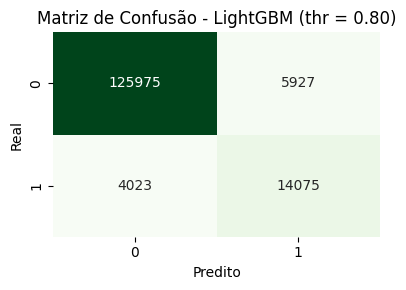

In [ ]:
# Aplicando o melhor threshold
y_pred_final_lgb = (y_proba_val_lgb >= 0.8).astype(int)

# Relatório
print("Relatório de Classificação - LightGBM (thr = 0.8)")
print(classification_report(y_val, y_pred_final_lgb, digits=4))

# Matriz de Confusão
cm_lgb_final = confusion_matrix(y_val, y_pred_final_lgb)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_lgb_final, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Matriz de Confusão - LightGBM (thr = 0.80)")
plt.xlabel("Predito"); plt.ylabel("Real")
plt.tight_layout()
plt.show()

## 8) Geração do Arquivo submission.csv para Kaggle

In [ ]:
# (Re)Treinamento no conjunto completo
lgb_final = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)
lgb_final.fit(X_nc, y)

# Prever probabilidades no dataset de teste
y_proba_test_final = lgb_final.predict_proba(df_test[X_nc.columns])[:, 1]

# Gerar o submission.csv com probabilidades
submission = pd.DataFrame({
    "id": df_test.index,
    "y": y_proba_test_final
})

# Exportar corretamente
submission.to_csv("submission.csv", index=False)

# Visualizar amostra
submission.head()

[LightGBM] [Info] Number of positive: 90488, number of negative: 659512
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069530 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1014
[LightGBM] [Info] Number of data points in the train set: 750000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120651 -> initscore=-1.986283
[LightGBM] [Info] Start training from score -1.986283


,id,y
0,750000,0.015592
1,750001,0.450788
2,750002,0.000973
3,750003,0.000268
4,750004,0.084746


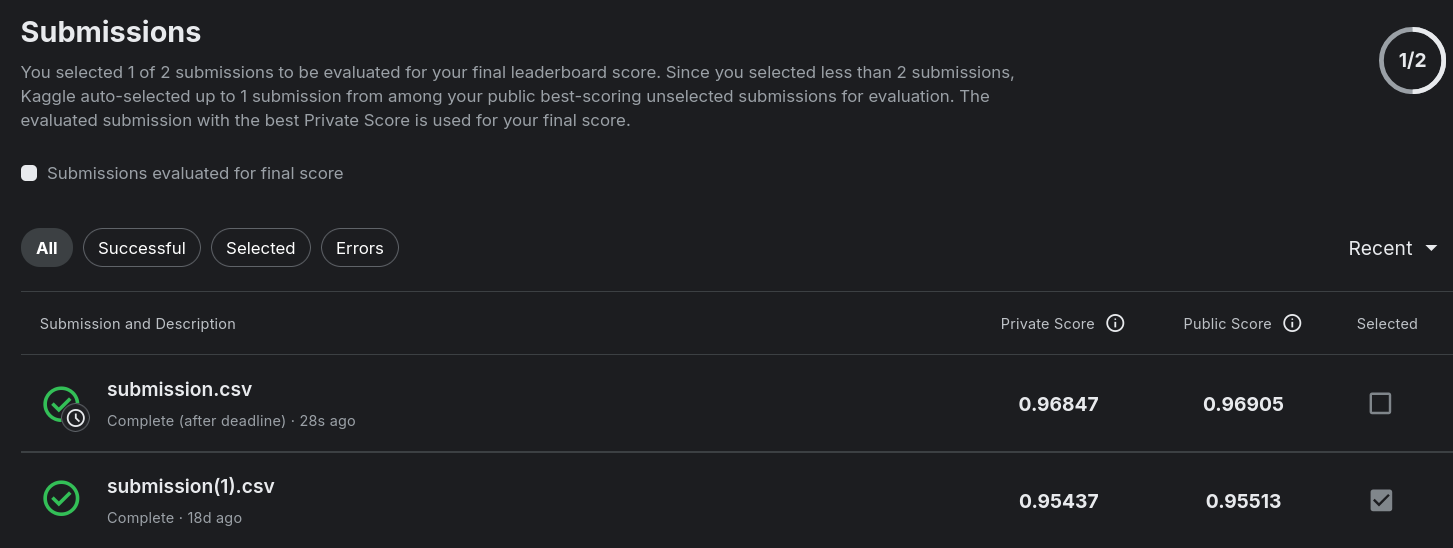